# Machine Learning Analysis — Bir Market Product Data

This notebook builds on the earlier data cleaning and statistical analysis performed in `analysis.ipynb`. The goal here is to apply machine learning models to the cleaned product dataset (`cleaned_products.csv`) to predict either `rating_score` or `new_price` based on available product features (`brand`, `category`, `old_price`, `discount`).

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Importing Dataset


In [99]:
df1=pd.read_csv('D:\\d_projects\\Bir_market\\analysis\\cleaned_products.csv')
df1.head()

,name,new_price,old_price,discount,rating_score,rating_count,brand,category
0,Paltaryuyan maşın Lanova LNVWM-60-WW,409.00,789.00,48.0,4.8,58,Lanova,Paltaryuyan maşın
1,Soyuducu Beko B1RCNK272G,727.98,944.99,23.0,4.5,48,Beko,Soyuducu
2,Paltaryuyan maşın Lanova LNVWM-60-TT,433.00,799.00,46.0,4.7,18,Lanova,Paltaryuyan maşın
3,Soyuducu Midea MDRB424FGF02O,858.93,1199.90,28.0,3.7,3,Midea,Soyuducu
4,Soyuducu Biryusa W920NF,675.00,1059.00,36.0,4.9,23,Biryusa,Soyuducu


## Price vs Rating Score — Full Dataset

The scatter plot below shows `new_price` against `rating_score` for the entire dataset (2200 products). A large cluster of points sits at `rating_score = 0`, spread across the full price range. This does not represent products with genuinely low ratings — it reflects products that had no rating data available in the original source, which were filled with 0 during data cleaning.

Before analyzing the real relationship between price and rating, these unrated products need to be filtered out, since including them would distort the correlation and any model trained on this data.

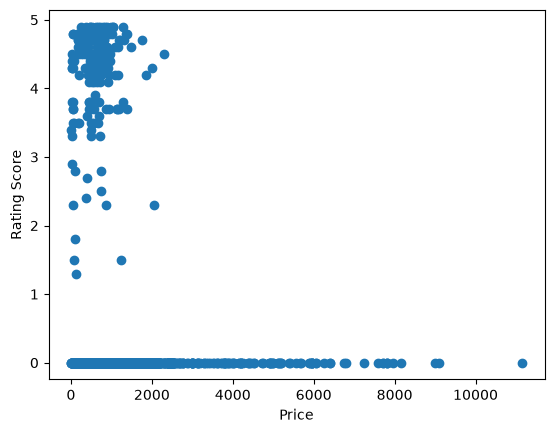

In [100]:
plt.scatter(df1['new_price'],df1['rating_score'])
plt.xlabel('Price')
plt.ylabel('Rating Score')
plt.show()

## Price vs Rating Score — Rated Products Only

After filtering to keep only products with both a rating count and a rating score greater than 0, the dataset was reduced to 197 products. The scatter plot below shows a much clearer picture: most rated products fall in the 0–1000 price range with ratings concentrated between 4.0 and 4.9.

The Pearson correlation coefficient between `new_price` and `rating_score` is **0.12**, indicating a very weak positive relationship. This suggests that price alone is not a strong predictor of a product's rating — other factors likely play a much bigger role in customer satisfaction.

In [101]:
df_with_rating = df1[(df1['rating_count'] > 0) & (df1['rating_score'] > 0)]
print(df_with_rating.shape)

(197, 8)


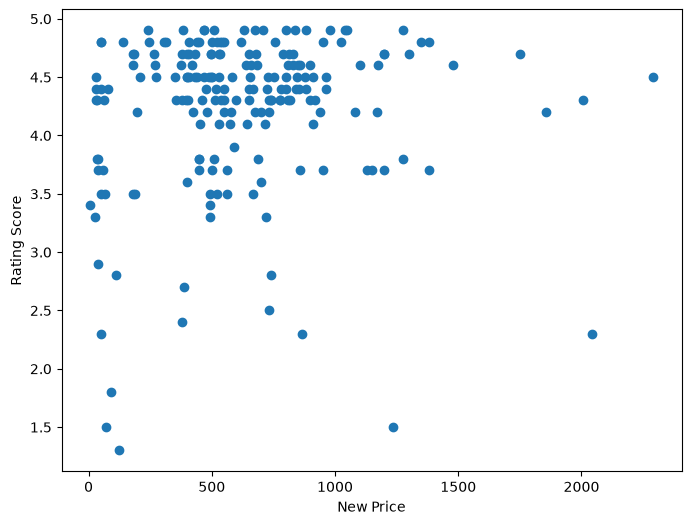

Correlation: 0.1206083373731053


In [102]:
plt.figure(figsize=(8,6))
plt.scatter(df_with_rating['new_price'], df_with_rating['rating_score'])
plt.xlabel('New Price')
plt.ylabel('Rating Score')
plt.show()
print(f"Correlation: {df_with_rating['new_price'].corr(df_with_rating['rating_score'])}")

## Predicting Rating Score with Linear Regression

In this section, we build a Linear Regression model to predict a product's `rating_score` based on its `brand`, `category`, `old_price`, and `discount`. Since the earlier correlation analysis showed only a weak relationship (r = 0.12) between price and rating alone, this model tests whether combining multiple features improves predictive power.

Rare brands and categories (fewer than 5 occurrences) were grouped into an "Other" category to reduce the number of one-hot encoded columns and limit overfitting risk, given the small dataset size (197 rows).

In [103]:
brand_counts=df_with_rating['brand'].value_counts()
rare_brands=brand_counts[brand_counts<5].index
df_with_rating['brand_grouped']=df_with_rating['brand'].apply(lambda x: 'Other' if x in rare_brands else x)
print(df_with_rating['brand_grouped'].value_counts())

brand_grouped
Other       40
Biryusa     32
No brand    18
Hoffmann    17
Samsung     16
Beko        14
LG          13
Indesit     10
Midea        9
Yoshiro      7
Kraft        6
Ardesto      5
Hisense      5
Bosch        5
Name: count, dtype: int64


In [104]:
category_counts=df_with_rating['category'].value_counts()
rare_categories=category_counts[category_counts<15].index
df_with_rating['category_grouped']=df_with_rating['category'].apply(lambda x: 'Other' if x in rare_categories else x)
print(df_with_rating['category_grouped'].value_counts())

category_grouped
Soyuducu             71
Paltaryuyan maşın    64
Other                41
Dondurucu            21
Name: count, dtype: int64


In [105]:
X =pd.get_dummies(df_with_rating[['brand_grouped','category_grouped','discount','old_price']], drop_first=True)
Y=df_with_rating['rating_score']

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(157, 18) (40, 18)


In [106]:
Scaler= StandardScaler()
X_train_scaler= Scaler.fit_transform(X_train)
X_test_scaler=Scaler.transform(X_test)


In [107]:
model= LinearRegression()
model.fit(X_train_scaler,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-0.06, 0.15,-0.1 ,..., 0.15, 0.14, 0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.217
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(18)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](18,)","[18.93,17.21,15.41,..., 5.52, 3.76, 2.27]"


In [108]:
y_pred=model.predict(X_test_scaler)
print(y_pred)

[3.03600792 4.29468936 4.20489433 4.03267183 4.24688192 4.20147323
 3.97052827 4.69189403 4.75844074 4.13719172 4.72811947 4.47768428
 4.3334461  4.08499391 4.34375003 3.22172447 4.33300439 3.6740638
 3.95588941 4.7177892  4.46961919 4.18227371 4.039538   4.38186249
 4.10083876 4.30622401 4.27159164 4.73357373 4.03856481 4.0620999
 4.27399248 4.12650911 4.24346848 4.53759812 4.11267689 4.49168564
 4.56151983 4.3050077  4.36810872 3.93371869]


In [109]:
print(model.coef_)
print(model.intercept_)

[-0.05613442  0.15470897 -0.09645481 -0.12522276 -0.25922693  0.00152023
 -0.09415526 -0.09189016 -0.03413641 -0.03584027 -0.0294205  -0.28262197
 -0.13710615 -0.14095369 -0.1616383   0.15140078  0.14377063  0.11735565]
4.2165605095541405


In [110]:
MAE=mean_absolute_error(Y_test,y_pred)
RMSE=mean_squared_error(Y_test,y_pred)
R2=r2_score(Y_test,y_pred)

print(f"mean_absolute_error: {MAE}")
print(f"root_mean_squared_error: {RMSE}")
print(f"r2_score: {R2}")

mean_absolute_error: 0.5208409395662205
root_mean_squared_error: 0.5765468498362639
r2_score: -0.47162746432586045


## Results and Conclusion — Rating Score Model

Despite feature engineering (grouping rare brands/categories) and feature scaling, the Linear Regression model failed to produce a useful prediction of `rating_score`:

- MAE: ~0.52
- RMSE: ~0.58
- R²: ~-0.47 (negative, meaning the model performs worse than simply predicting the mean rating for every product)

**Conclusion:** The available features (`brand`, `category`, `old_price`, `discount`) do not contain enough signal to reliably predict `rating_score`. This is consistent with the earlier correlation analysis, which found only a very weak relationship (r = 0.12) between price and rating. Ratings are likely driven by factors not captured in this dataset, such as product quality, durability, or actual customer experience.

Given this finding, the next section shifts to a different and more tractable target: predicting `new_price` from the same set of features, where a stronger and more logical relationship is expected (e.g., brand and category are known to correlate with pricing).

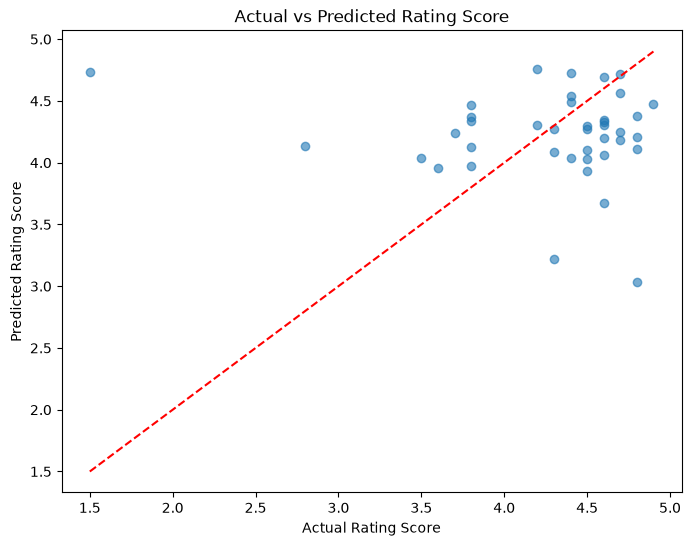

In [97]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test,y_pred, alpha=0.6)  # rating modelinin öz dəyişən adlarını yaz
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Rating Score')
plt.ylabel('Predicted Rating Score')
plt.title('Actual vs Predicted Rating Score')
plt.show()

## Actual vs Predicted Rating Score

The scatter plot below visualizes the poor performance of the rating prediction model. Most predictions cluster tightly between 4.0 and 4.3, regardless of the actual rating score, which ranges much more widely (from about 3.0 to 4.75). The points deviate significantly from the ideal red dashed line, especially for products with lower actual ratings, where the model consistently overpredicts. This confirms visually what the negative R² score already indicated: the model fails to capture any meaningful pattern between the features (brand, category, price, discount) and the actual rating scores, and instead tends to predict values close to the dataset's average rating regardless of input.

## Predicting Price with Linear Regression

Having found that `rating_score` could not be reliably predicted from the available features, this section shifts to a different and more tractable target: `new_price`. A Linear Regression model was trained using `brand_grouped`, `category_grouped`, and `discount` as features. The `old_price`, `rating_score`, and `rating_count` columns were excluded to avoid data leakage — `old_price` is mathematically tied to `new_price`, and rating information would not be available before a product's price is set in a real-world scenario.

In [75]:
brand_counts=df1['brand'].value_counts()
rare_brands=brand_counts[brand_counts<5].index
df1['brand_grouped']=df1['brand'].apply(lambda x: 'Other' if x in rare_brands else x)
print(df_with_rating['brand_grouped'].value_counts())

brand_grouped
Other       40
Biryusa     32
No brand    18
Hoffmann    17
Samsung     16
Beko        14
LG          13
Indesit     10
Midea        9
Yoshiro      7
Kraft        6
Ardesto      5
Hisense      5
Bosch        5
Name: count, dtype: int64


In [77]:
category_counts=df1['category'].value_counts()
rare_categories=category_counts[category_counts<15].index
df1['category_grouped']=df1['category'].apply(lambda x: 'Other' if x in rare_categories else x)
print(df1['category_grouped'].value_counts())

category_grouped
Soyuducu              893
Paltaryuyan maşın     535
Dondurucu             289
Digər                 145
Qabyuyan maşın        130
Qaz plitəsi           102
Mini soyuducu          74
Buz generatoru         66
Quruducu               40
Ticarət soyuducusu     25
Paltar qurudan         17
Other                  14
Name: count, dtype: int64


In [79]:
x1=pd.get_dummies(df1[['brand_grouped','category_grouped','discount']], drop_first=True)
y1=df1['new_price']

x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.2,random_state=42)
print(x1_train.shape,x1_test.shape)

(1864, 62) (466, 62)


In [80]:
scalar=StandardScaler()
x1_train_scalar=scalar.fit_transform(x1_train)
x1_test_scalar=scalar.transform(x1_test)

In [82]:
model1=LinearRegression()
model1.fit(x1_train_scalar,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](62,)","[-86.19,-54.89, 6.94,...,-51.85, 25.2 ,-18.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,998.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,62
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(62)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](62,)","[59.79,56.77,55.06,...,26.86, 7.48, 6.68]"


In [86]:
y1_pred=model1.predict(x1_test_scalar)
print(y1_pred)

[ 1.54686772e+03  4.54056961e+02  1.91798407e+03  7.54287763e+02
  7.96432457e+02  1.03331102e+03  1.35613587e+03  1.54011418e+03
  1.43949133e+03  8.74389119e+02  5.26221196e+02  1.83789685e+03
  7.79346505e+02  3.58959260e+03  1.14313288e+03  1.57588918e+03
  3.58109878e+02  5.89660453e+02  6.48552327e+02  3.64016590e+02
  1.62190136e+03  1.61200408e+03  4.67361660e+02  1.14117491e+03
  2.22430092e+03  1.01830429e+03  1.39615381e+03  1.98296189e+03
  5.51458042e+02  7.91430215e+02  8.49377905e+02  3.36776312e+02
  1.46266596e+03  9.53733457e+02  7.41394658e+02  8.11426058e+02
  9.95410333e+02  5.57590596e+02  6.93572512e+02  8.52317105e+02
  1.55870047e+03  7.94353234e+02  8.52073985e+02  1.31033973e+03
  3.24269655e+02 -1.96426353e+02  7.53584593e+02  6.93572512e+02
  6.79254120e+02  1.21029488e+03  9.69198818e+02  1.21816653e+03
  5.69651482e+02  3.99630801e+03  8.34371176e+02  7.84745308e+02
 -1.06385983e+02  1.09404110e+03  1.62190136e+03  1.03416306e+03
  2.05914561e+03  7.97130

In [95]:
Mae_1=mean_absolute_error(y1_test,y1_pred)
Rmse_1=np.sqrt(mean_squared_error(y1_test,y1_pred))
r2_1=r2_score(y1_test,y1_pred)

print(f"Mean absolute error {Mae_1}")
print(f"Root mean squared error  {Rmse_1}")
print(f" r score  {r2_1}")

Mean absolute error 371.4973584612689
Root mean squared error  614.0224237330737
 r score  0.5905644301935873


## Results and Conclusion — Price Prediction Model

Results on the test set:
- MAE: ~371 AZN
- RMSE: ~614 AZN
- R²: ~0.59

Unlike the rating prediction model, this model performs reasonably well — brand and category explain a meaningful portion (59%) of the variance in product price, which aligns with the intuitive expectation that pricing is closely tied to brand positioning and product category. The remaining unexplained variance likely comes from product-specific factors not captured in this dataset, such as technical specifications, size, or capacity.

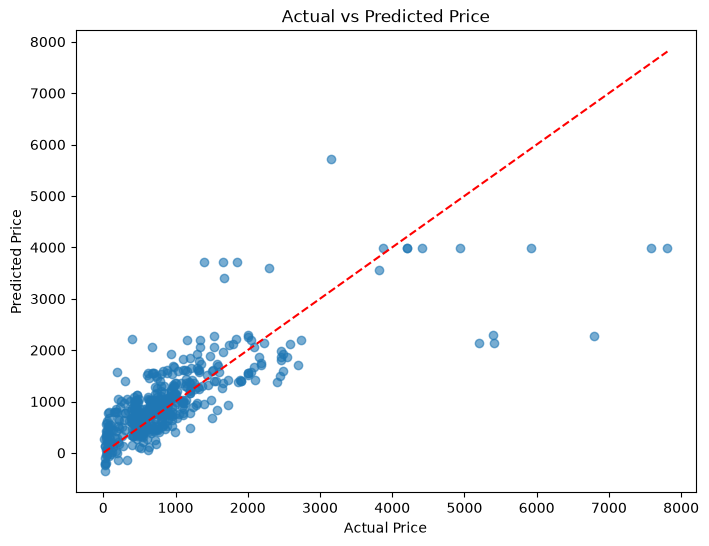

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(y1_test, y1_pred, alpha=0.6)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()


## Actual vs Predicted Price

The scatter plot below compares the model's predicted prices against the actual prices in the test set. For lower-priced products (roughly 0–2000 AZN, where most of the data is concentrated), the points cluster closely around the ideal red dashed line, showing accurate predictions in this range.

However, the model struggles at the higher end: several expensive products (actual price above 4000 AZN) are predicted at only ~4000 AZN, indicating the model underpredicts prices for premium products — likely because there are too few high-price examples in the training data for the model to learn this range well. A few products are also overpredicted (e.g., points above the line around 1500–2500 actual price), and one notable outlier near 3000 actual price is predicted at over 5700.

Overall, this pattern is consistent with the R² of 0.59: the model captures the general pricing trend well for typical products, but has limited ability to generalize to rare, high-priced items — a common limitation when the training data is imbalanced toward lower price ranges.